# Smart Grid Load Forecasting — Study Notebook (book2, LOADED version)

This is the local (Windows / PyCharm) version of the same notebook you ran on **Kaggle**.
The big difference: **the model is already trained and saved**, so the slow training cells are **commented out** — this notebook loads the saved model and focuses on **using**, **visualizing**, and **understanding** the results.

## What changed vs the Kaggle version
- **Data path** now points to your **local** folder (`D:\Users\user\...`), not `/kaggle/input`.
- **Cell 13 (Model training)** is commented out — we don't retrain.
- **Cell 19 (retrain best model)** is commented out — we load `best_rf.joblib` instead.
- All the **study comments** are kept so you can still learn what each part does.

> **IMPORTANT:** You must have `best_rf.joblib` and `feature_cols.joblib` in the same folder as this notebook (or update the `MODEL_PATH` below). They were created on Kaggle — download them and put them here.

In [21]:
# ============================================================
#  CELL 0 - SETTINGS (the 'control panel')
# ============================================================
import os

# --- WHERE IS THE DATA? ---
# book1 wrote the cleaned file. We try the Windows path first, then fall
# back to Linux. Try/except lets it run on both.
DATA_CANDIDATES = [
    r"D:\Users\user\PycharmProjects\SMART_GRID_LOAD_FORECASTING\data_raw\merged_long_df.csv",
    r"/home/jovyan/projects/time_series_notebook/data_raw/merged_long_df.csv",
    r"merged_long_df.csv",
]
DATA_PATH = next((p for p in DATA_CANDIDATES if os.path.exists(p)), DATA_CANDIDATES[0])
print("Using data file:", DATA_PATH)
print("File exists:", os.path.exists(DATA_PATH))

# --- COLUMN NAMES ---
DATE_COL   = "Datetime"
TARGET     = "MW"
SERIES_ID  = "region"
FREQ       = "h"

# --- MODEL SETTINGS ---
FORECAST_HORIZON = 30
N_TEST_PERIODS  = 30
RANDOM_STATE    = 42
SEASONAL_PERIODS = 24   # hourly data -> 24 hour daily cycle
MAX_TRAIN_POINTS = 8760  # 1 year of hourly data
N_SPLITS = 2

# --- WHERE ARE THE SAVED MODEL FILES? ---
# These come from Kaggle (joblib.dump). Put them next to this notebook,
# or change the paths to wherever you downloaded them.
MODEL_FILE    = r"D:\Users\user\PycharmProjects\SMART_GRID_LOAD_FORECASTING\models\best_rf_clean.joblib"
FEATURES_FILE = r"D:\Users\user\PycharmProjects\SMART_GRID_LOAD_FORECASTING\models\feature_cols_clean.joblib"

# --- OPTIONAL HEAVY MODELS (NOT used here) ---
RUN_SARIMA      = False
RUN_PROPHET     = False
RUN_LSTM        = False
RUN_AUTO_ARIMA  = False

print("Settings ready.")


Using data file: D:\Users\user\PycharmProjects\SMART_GRID_LOAD_FORECASTING\data_raw\merged_long_df.csv
File exists: True
Settings ready.


### Cell 1 - Import the libraries
Same imports as before. Optional heavy ones stay gated (off).

In [22]:
# ============================================================
#  CELL 1 - IMPORT LIBRARIES
# ============================================================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
import joblib   # to save / load the trained model

if RUN_SARIMA or RUN_AUTO_ARIMA:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    HAVE_SARIMA = True
else:
    HAVE_SARIMA = False
if RUN_PROPHET:
    from prophet import Prophet
    HAVE_PROPHET = True
else:
    HAVE_PROPHET = False
if RUN_LSTM:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    from tensorflow.keras.callbacks import EarlyStopping
    HAVE_TF = True
else:
    HAVE_TF = False

print("Libraries imported.")


Libraries imported.


### Cell 2 - Score metrics (same as before)

In [23]:
# ============================================================
#  CELL 2 - SCORING METRICS
# ============================================================
def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error, in %. Lower = better."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom[denom == 0] = 1e-9
    return 200 * np.mean(np.abs(y_pred - y_true) / denom)

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error, in %. Lower = better."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

print("Metrics defined.")


Metrics defined.


### Cell 3 - Load the data (local path)

In [24]:
# ============================================================
#  CELL 3 - LOAD DATA
# ============================================================
KEEP_COLS = [
    DATE_COL, TARGET, SERIES_ID,
    "hour", "day_of_week", "month", "year", "is_weekend",
    "hour_sin", "hour_cos", "day_of_week_sin", "day_of_week_cos",
    "month_sin", "month_cos",
    "load_lag_1h", "load_lag_24h", "load_lag_168h", "load_lag_720h",
    "load_roll_mean_24h", "load_roll_mean_168h", "load_roll_std_24h", "load_roll_std_168h",
    "is_holiday", "is_month_start", "is_month_end",
    "fourier_sin_1", "fourier_cos_1", "fourier_sin_2", "fourier_cos_2",
]
df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL], usecols=KEEP_COLS)
print(f"Data shape: {df.shape}")
print(df[[DATE_COL, SERIES_ID, TARGET]].head())


Data shape: (1090127, 29)
             Datetime region       MW
0 2004-10-01 01:00:00    AEP  12379.0
1 2004-10-01 02:00:00    AEP  11935.0
2 2004-10-01 03:00:00    AEP  11692.0
3 2004-10-01 04:00:00    AEP  11597.0
4 2004-10-01 05:00:00    AEP  11681.0


### Cell 4 - Sanity check (regions, dates, duplicates)

In [25]:
# ============================================================
#  CELL 4 - SANITY CHECK
# ============================================================
print("Regions:", sorted(df[SERIES_ID].unique()))
print("Date range:", df[DATE_COL].min(), "->", df[DATE_COL].max())
print("Missing MW:", df[TARGET].isna().sum())
dupes = df.duplicated(subset=[SERIES_ID, DATE_COL]).sum()
print("Duplicate (region, timestamp):", dupes)
if dupes:
    df = df.drop_duplicates(subset=[SERIES_ID, DATE_COL], keep="first")
    print(f"Dropped dups -> {df.shape}")


Regions: ['AEP', 'COMED', 'DAYTON', 'DEOK', 'DOM', 'DUQ', 'EKPC', 'FE', 'NI', 'PJME', 'PJMW', 'PJM_Load']
Date range: 1998-04-01 01:00:00 -> 2018-08-03 00:00:00
Missing MW: 0
Duplicate (region, timestamp): 0


### Cell 5 - Count missing hours

In [26]:
# ============================================================
#  CELL 5 - MISSING HOURS
# ============================================================
first_region = df[SERIES_ID].iloc[0]
sample = df[df[SERIES_ID] == first_region]
full_range = pd.date_range(sample[DATE_COL].min(), sample[DATE_COL].max(), freq=FREQ)
n_gaps = len(full_range) - sample[DATE_COL].nunique()
print(f"Region '{first_region}': expected {len(full_range)}h, got {sample[DATE_COL].nunique()}, gaps={n_gaps}")


Region 'AEP': expected 121296h, got 121269, gaps=27


### Cell 6 - Plot one region (the raw data)

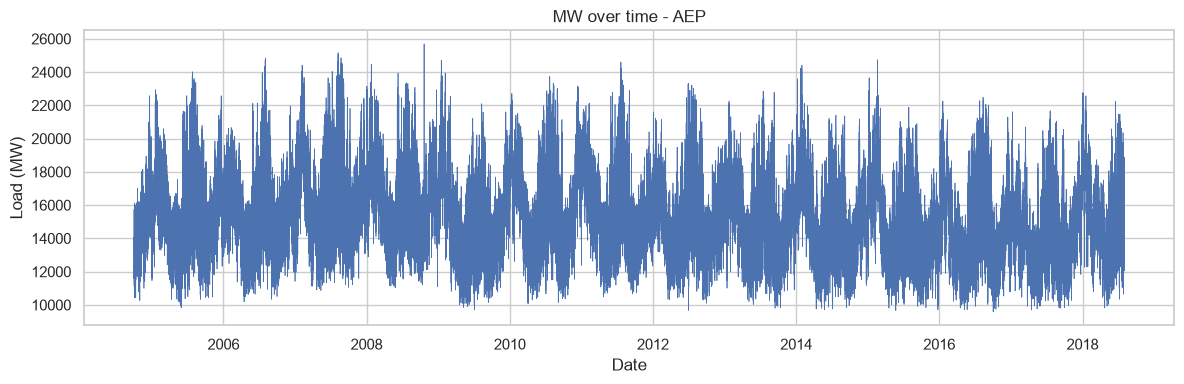

In [27]:
# ============================================================
#  CELL 6 - PLOT LOAD OVER TIME
# ============================================================
plot_df = df[df[SERIES_ID] == first_region].copy()
plt.figure(figsize=(12, 4))
plt.plot(plot_df[DATE_COL], plot_df[TARGET], linewidth=0.5)
plt.title(f"{TARGET} over time - {first_region}")
plt.xlabel("Date"); plt.ylabel("Load (MW)")
plt.tight_layout(); plt.show()


### Cell 7 - Rolling mean / std (stationarity hint)

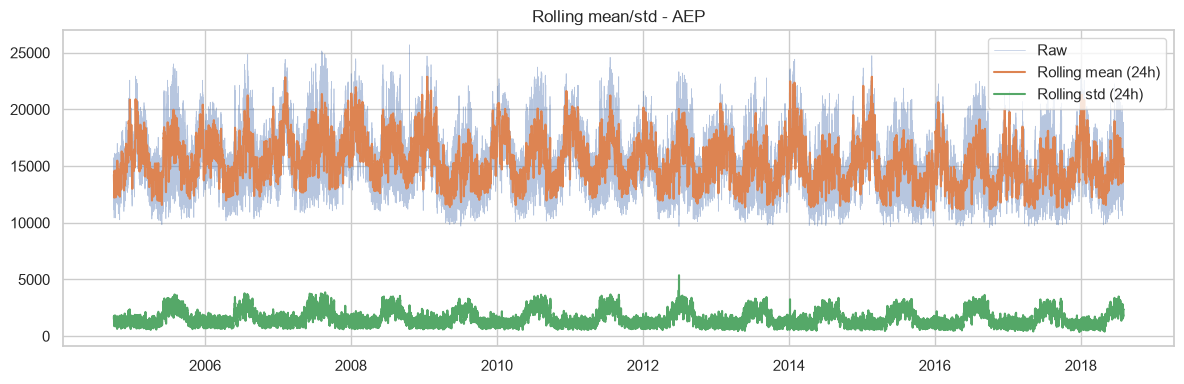

In [28]:
# ============================================================
#  CELL 7 - ROLLING MEAN & STD
# ============================================================
roll = plot_df.set_index(DATE_COL)[TARGET]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(roll.index, roll, label="Raw", alpha=0.4, linewidth=0.5)
ax.plot(roll.index, roll.rolling(24).mean(), label="Rolling mean (24h)", linewidth=1.5)
ax.plot(roll.index, roll.rolling(24).std(), label="Rolling std (24h)", linewidth=1.5)
ax.legend(); ax.set_title(f"Rolling mean/std - {first_region}")
plt.tight_layout(); plt.show()


### Cell 8 - ADF stationarity test (informational)

In [29]:
# ============================================================
#  CELL 8 - ADF STATIONARITY TEST
# ============================================================
def adf_test(series, label):
    series = series.dropna()
    stat, p, *_ = adfuller(series)
    print(f"--- {label} ---")
    print(f"ADF stat: {stat:.3f} | p: {p:.4f}")
    print("  stationary" if p < 0.05 else "  NON-stationary (may need differencing)")
    return p
adf_test(roll, "Original (" + first_region + ")")
adf_test(roll.diff().dropna(), "After 1st difference")


--- Original (AEP) ---
ADF stat: -18.306 | p: 0.0000
  stationary
--- After 1st difference ---
ADF stat: -44.967 | p: 0.0000
  stationary


0.0

### Cell 9 - Chronological train/test split (per region)

In [30]:
# ============================================================
#  CELL 9 - TRAIN/TEST SPLIT
# ============================================================
df_feat = df.copy()
df_feat = df_feat.sort_values([SERIES_ID, DATE_COL]).reset_index(drop=True)

# Drop rows whose lag features are NaN (first rows of each region).
lag_cols = [c for c in df_feat.columns if c.startswith("load_lag_")]
df_feat = df_feat.dropna(subset=lag_cols).reset_index(drop=True)

# Convert region names -> integer codes (ML needs numbers).
region_codes = sorted(df_feat[SERIES_ID].unique())
region_code_map = {r: i for i, r in enumerate(region_codes)}
df_feat[SERIES_ID] = df_feat[SERIES_ID].map(region_code_map)
print("Region -> code:", region_code_map)

def chrono_split(g):
    return g.iloc[:-N_TEST_PERIODS], g.iloc[-N_TEST_PERIODS:]

train_parts, test_parts = [], []
for _, g in df_feat.groupby(SERIES_ID, sort=False):
    tr, te = chrono_split(g)
    if len(tr) >= N_TEST_PERIODS:
        train_parts.append(tr); test_parts.append(te)
train_df = pd.concat(train_parts).reset_index(drop=True)
test_df  = pd.concat(test_parts).reset_index(drop=True)
print(f"Train: {train_df.shape}  Test: {test_df.shape}")


Region -> code: {'AEP': 0, 'COMED': 1, 'DAYTON': 2, 'DEOK': 3, 'DOM': 4, 'DUQ': 5, 'EKPC': 6, 'FE': 7, 'NI': 8, 'PJME': 9, 'PJMW': 10, 'PJM_Load': 11}
Train: (1080268, 29)  Test: (360, 29)


### Cell 10 - Walk-forward CV folds (for reference)

In [31]:
# ============================================================
#  CELL 10 - WALK-FORWARD CV (kept for study; model already trained)
# ============================================================
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=N_TEST_PERIODS)
fold_train_parts = [[] for _ in range(N_SPLITS)]
fold_val_parts   = [[] for _ in range(N_SPLITS)]
for region, g in df_feat.groupby(SERIES_ID, sort=False):
    g = g.reset_index(drop=True)
    if len(g) <= N_TEST_PERIODS * (N_SPLITS + 1):
        continue
    for k, (tr_idx, val_idx) in enumerate(tscv.split(g)):
        fold_train_parts[k].append(g.iloc[tr_idx])
        fold_val_parts[k].append(g.iloc[val_idx])
folds = []
for k in range(N_SPLITS):
    tr = pd.concat(fold_train_parts[k]).reset_index(drop=True)
    va = pd.concat(fold_val_parts[k]).reset_index(drop=True)
    folds.append((tr, va))
print(f"Built {len(folds)} fold(s) across {df_feat[SERIES_ID].nunique()} regions")


Built 2 fold(s) across 12 regions


### Cell 11 - Evaluation engine (kept for reference)

In [32]:
# ============================================================
#  CELL 11 - EVAL ENGINE + per_region
# ============================================================
results = {}
def evaluate_forecast(name, forecast_fn):
    scores = {"MAE": [], "RMSE": [], "sMAPE": []}
    for tr, val in folds:
        try:
            preds = forecast_fn(tr, val)
        except Exception as e:
            print(f"  {name}: fold failed ({e})")
            continue
        y = val[TARGET].values
        scores["MAE"].append(mean_absolute_error(y, preds))
        scores["RMSE"].append(np.sqrt(mean_squared_error(y, preds)))
        scores["sMAPE"].append(smape(y, preds))
    summary = {m: (np.mean(v) if v else np.nan) for m, v in scores.items()}
    results[name] = summary
    print(f"{name}: MAE={summary['MAE']:.2f} RMSE={summary['RMSE']:.2f} sMAPE={summary['sMAPE']:.2f}%")
    return summary

def per_region(fn):
    def wrapped(tr, val):
        preds = []
        for region, g_val in val.groupby(SERIES_ID, sort=False):
            g_tr = tr[tr[SERIES_ID] == region]
            if len(g_tr) == 0 or len(g_tr) < 2:
                preds.append(np.full(len(g_val), np.nan)); continue
            try:
                preds.append(fn(g_tr, g_val))
            except Exception as e:
                preds.append(np.full(len(g_val), np.nan))
        return np.concatenate(preds)
    wrapped.__name__ = fn.__name__
    return wrapped


### Cell 12 - Define features (NO training here)
We build `FEATURE_COLS` from the data, but we do **NOT** retrain the ML models (that was done on Kaggle). The `evaluate_forecast(...)` calls are **commented out** so this cell runs instantly.

In [33]:
# ============================================================
#  CELL 12 - FEATURE COLUMNS + CAPPED DATA (no training)
# ============================================================
FEATURE_COLS = [c for c in df_feat.columns if c not in [DATE_COL, TARGET, SERIES_ID]]
print("FEATURE_COLS:", FEATURE_COLS)

# Cap data to the most recent MAX_TRAIN_POINTS per region (matches Kaggle).
# NOTE: use groupby(...).tail(n) NOT groupby(...).apply(...).
# In pandas 3.x, groupby.apply() DROPS the grouping column ('region'),
# which causes 'KeyError: region' later. groupby.tail() keeps every column
# and returns just the last n rows of each region - correct and fast.
train_df_ml = train_df.groupby(SERIES_ID, sort=False).tail(MAX_TRAIN_POINTS).reset_index(drop=True)
test_df_ml  = test_df.groupby(SERIES_ID, sort=False).tail(MAX_TRAIN_POINTS).reset_index(drop=True)
print(f"Capped: train {train_df_ml.shape}, test {test_df_ml.shape}")
print("test_df_ml has 'region' column:", SERIES_ID in test_df_ml.columns)

# --- MODEL TRAINING (COMMENTED OUT - model already trained & saved) ---
# To RE-TRAIN on your own machine, uncomment the lines below. Warning: it
# takes a while (12 regions x folds x 3 ML models).
#
# def ml_forecast(model_class, **kwargs):
#     def _forecast(tr, val):
#         model = model_class(**kwargs)
#         model.fit(tr[FEATURE_COLS], tr[TARGET])
#         return model.predict(val[FEATURE_COLS])
#     return _forecast
#
# print("--- Fast ML models ---")
# evaluate_forecast("Random Forest", ml_forecast(RandomForestRegressor, n_estimators=120, random_state=RANDOM_STATE, n_jobs=-1))
# evaluate_forecast("XGBoost",      ml_forecast(xgb.XGBRegressor, random_state=RANDOM_STATE, n_jobs=-1))
# evaluate_forecast("LightGBM",     ml_forecast(lgb.LGBMRegressor, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))


FEATURE_COLS: ['hour', 'day_of_week', 'month', 'year', 'is_weekend', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'load_lag_1h', 'load_lag_24h', 'load_lag_168h', 'load_lag_720h', 'load_roll_mean_24h', 'load_roll_std_24h', 'load_roll_mean_168h', 'is_holiday', 'is_month_start', 'is_month_end', 'load_roll_std_168h', 'fourier_sin_1', 'fourier_cos_1', 'fourier_sin_2', 'fourier_cos_2']
Capped: train (105120, 29), test (360, 29)
test_df_ml has 'region' column: True


### Cell 13 - Load the trained model (NEW - replaces training)
This cell **loads** the Random Forest you trained and saved on Kaggle, plus the feature list. `joblib.load` is fast — no training happens here.

In [34]:
# ============================================================
#  CELL 13 - LOAD THE SAVED MODEL (no training)
# ============================================================
import os
if not os.path.exists(MODEL_FILE):
    # If the file isn't next to the notebook, tell the user where to put it.
    print("MISSING:", MODEL_FILE, "- download it from Kaggle and put it in the notebook's folder.")
    print("Data is still loaded; model cells below will fail until the file exists.")

# Load the trained model and the feature columns it expects.
# NOTE: the saved feature list from Kaggle is authoritative for the model.
saved_features = joblib.load(FEATURES_FILE)   # list of column names the model was trained on
model = joblib.load(MODEL_FILE)               # the trained RandomForestRegressor
print("Model loaded:", type(model).__name__)
print("Model expects this many features:", len(saved_features))
print("Features:", saved_features)


Model loaded: RandomForestRegressor
Model expects this many features: 26
Features: ['hour', 'day_of_week', 'month', 'year', 'is_weekend', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'load_lag_1h', 'load_lag_24h', 'load_lag_168h', 'load_lag_720h', 'load_roll_mean_24h', 'load_roll_std_24h', 'load_roll_mean_168h', 'is_holiday', 'is_month_start', 'is_month_end', 'load_roll_std_168h', 'fourier_sin_1', 'fourier_cos_1', 'fourier_sin_2', 'fourier_cos_2']


### Cell 14 - Predict on the test set
Now we actually **use** the loaded model: feed it the test features and get predictions, then score them against the true loads.

In [35]:
# ============================================================
#  CELL 14 - PREDICT + SCORE (uses the LOADED model)
# ============================================================
BEST_MODEL_NAME = "Random Forest"

# The model must see the SAME columns it was trained on, in the SAME order.
# So we select saved_features from test_df_ml (the capped test set).
y_pred = model.predict(test_df_ml[saved_features])
y_true = test_df_ml[TARGET].values

print(f"MAE:   {mean_absolute_error(y_true, y_pred):.3f}")
print(f"RMSE:  {np.sqrt(mean_squared_error(y_true, y_pred)):.3f}")
print(f"sMAPE: {smape(y_true, y_pred):.2f}%")
print(f"MAPE:  {mape(y_true, y_pred):.2f}%")


MAE:   141.607
RMSE:  248.517
sMAPE: 1.17%
MAPE:  1.17%


### Cell 15 - Forecast vs actual plot (one region)
Shows the last few training hours + the test window, with the forecast drawn as a dashed red line. Great visual for your report.

columns: ['Datetime', 'region', 'MW', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'load_lag_1h', 'load_lag_24h', 'load_lag_168h', 'load_lag_720h', 'load_roll_mean_24h', 'load_roll_std_24h', 'load_roll_mean_168h', 'is_holiday', 'is_month_start', 'is_month_end', 'load_roll_std_168h', 'fourier_sin_1', 'fourier_cos_1', 'fourier_sin_2', 'fourier_cos_2']


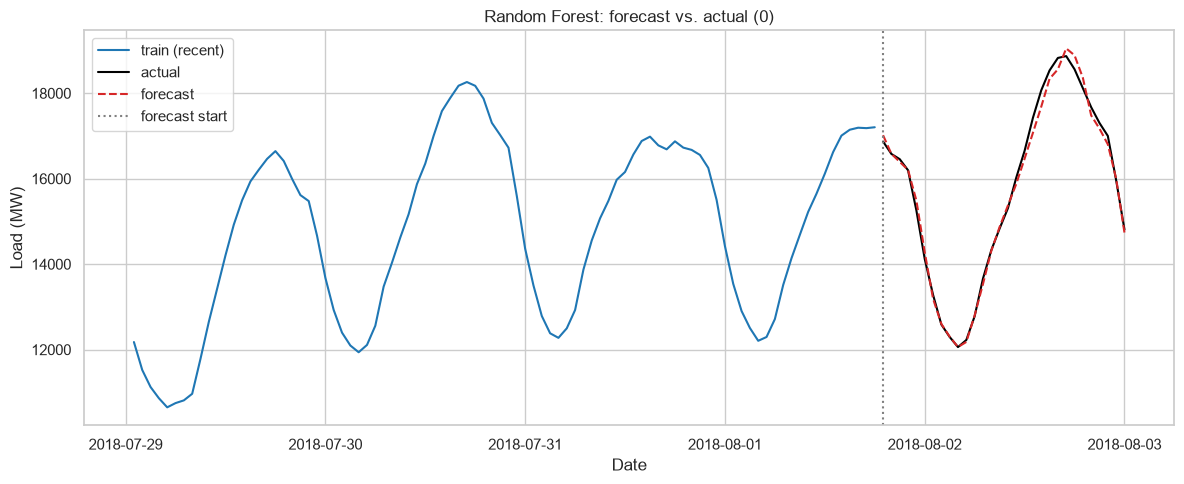

In [36]:
# ============================================================
#  CELL 15 - FORECAST vs ACTUAL (one region)
# ============================================================
CONTEXT_PERIODS = N_TEST_PERIODS * 3

# Pick ONE region so train-context and test come from the SAME series.
print("columns:", list(test_df_ml.columns))   # ← shows whether 'region' exists
ONE = test_df_ml[SERIES_ID].iloc[0]
ctx  = train_df_ml[train_df_ml[SERIES_ID] == ONE].iloc[-CONTEXT_PERIODS:]
test = test_df_ml[test_df_ml[SERIES_ID] == ONE]

# Predict on THIS region's rows (do not reuse a stale y_pred).
yp_one = model.predict(test[saved_features])
yt_one = test[TARGET].values

plt.figure(figsize=(12, 5))
plt.plot(ctx[DATE_COL],  ctx[TARGET],  label="train (recent)", color="tab:blue")
plt.plot(test[DATE_COL], yt_one,        label="actual",   color="black")
plt.plot(test[DATE_COL], yp_one,        label="forecast", color="tab:red", linestyle="--")
plt.axvline(test[DATE_COL].iloc[0], color="gray", linestyle=":", label="forecast start")
plt.legend()
plt.title(f"{BEST_MODEL_NAME}: forecast vs. actual ({ONE})")
plt.xlabel("Date"); plt.ylabel("Load (MW)")
plt.tight_layout(); plt.show()


### Cell 16 - Residual analysis (is the model missing anything?)
Residuals = actual − predicted. If they look random and the Ljung-Box **p ≥ 0.05**, the model captured the pattern. If p < 0.05 or you see a pattern, something is still missing.

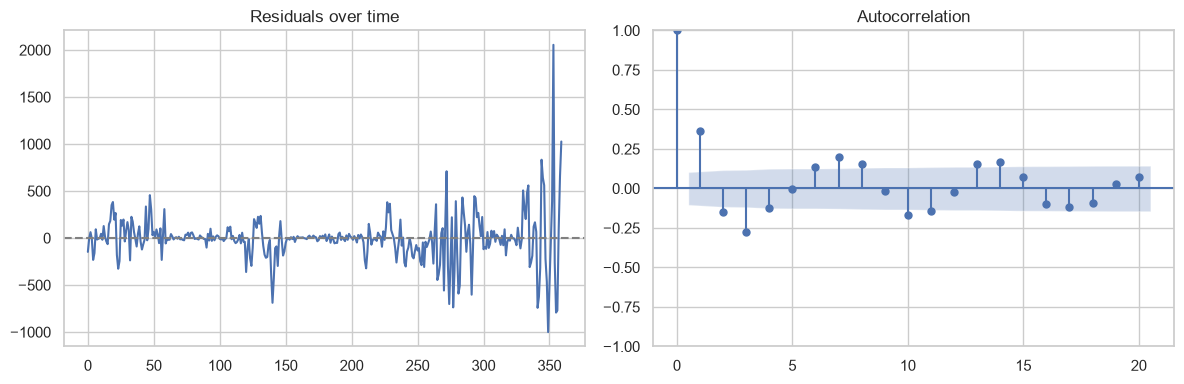

       lb_stat     lb_pvalue
10  129.644017  5.521361e-23

Verdict: Residuals still have pattern - model underfits


In [37]:
# ============================================================
#  CELL 16 - RESIDUAL ANALYSIS
# ============================================================
residuals = y_true - y_pred        # from Cell 14 (whole test set)
resid_s = pd.Series(residuals)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(len(residuals)), residuals)
axes[0].axhline(0, color="gray", linestyle="--")
axes[0].set_title("Residuals over time")
plot_acf(resid_s, lags=min(20, len(resid_s)//2 - 1), ax=axes[1])
plt.tight_layout(); plt.show()

lb_lag = min(10, len(resid_s) - 1)
lb_result = acorr_ljungbox(resid_s, lags=[lb_lag], return_df=True)
print(lb_result)
p = lb_result["lb_pvalue"].iloc[0]
print("\nVerdict:", "Residuals look random (good)" if p >= 0.05 else "Residuals still have pattern - model underfits")


### Cell 17 - Feature importance (what did the model learn?)
Random Forest can tell us which features mattered most. This is gold for the "explanation / RAG" side of your project: it shows *why* the model predicts what it does.

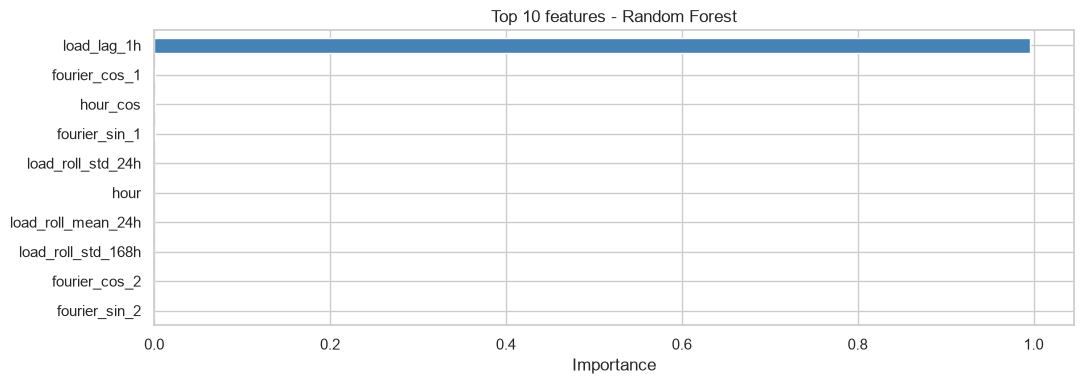

In [38]:
# ============================================================
#  CELL 17 - FEATURE IMPORTANCE
# ============================================================
imp = pd.Series(model.feature_importances_, index=saved_features).sort_values(ascending=False)
imp.head(10).plot(kind="barh", color="steelblue")
plt.title("Top 10 features - Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()


### Cell 18 - Confirm the model saves & reloads
Optional but good practice: proves the model file is valid and reusable later.

In [39]:
# ============================================================
#  CELL 18 - SAVE + RELOAD CHECK
# ============================================================
joblib.dump(model, MODEL_FILE)              # overwrite with same-version save
joblib.dump(saved_features, FEATURES_FILE)
print("Saved:", MODEL_FILE, "+", FEATURES_FILE)

# Reload and do a quick predict to confirm everything still works.
loaded = joblib.load(MODEL_FILE)
y_check = loaded.predict(test_df_ml[saved_features])
print("Reload OK - predictions shape:", y_check.shape)


Saved: D:\Users\user\PycharmProjects\SMART_GRID_LOAD_FORECASTING\models\best_rf_clean.joblib + D:\Users\user\PycharmProjects\SMART_GRID_LOAD_FORECASTING\models\feature_cols_clean.joblib
Reload OK - predictions shape: (360,)


### Cell 19 - Make a prediction from the saved model
This runs the **loaded** Random Forest on one region's test rows and prints the actual vs predicted values. Perfect for your report: it shows the model *in action* without any retraining.

In [40]:
# ============================================================
#  CELL 19 - MAKE A PREDICTION FROM THE SAVED MODEL
# ============================================================
# The model is already loaded (Cell 13). We just feed it features and read
# the predictions. No training happens here - it is instant.

# Pick which region to show: change the number to see another one.
# 0=AEP 1=COMED 2=DAYTON 3=DEOK 4=DOM 5=DUQ 6=EKPC 7=FE 8=NI 9=PJME 10=PJMW 11=PJM_Load
REGION_TO_SHOW = 0

# Take that region's test rows ONLY (same 30-hour window used for scoring).
region_test = test_df_ml[test_df_ml[SERIES_ID] == REGION_TO_SHOW].reset_index(drop=True)
print(f"Region code {REGION_TO_SHOW}: {len(region_test)} test rows")

# Predict: the model must receive exactly the columns it was trained on.
region_pred = model.predict(region_test[saved_features])

# Put side by side: timestamp, actual load, predicted load, and the error.
pred_df = pd.DataFrame({
    "Datetime": region_test[DATE_COL],
    "Actual_MW": region_test[TARGET].values,
    "Predicted_MW": region_pred,
})
pred_df["Error_MW"] = pred_df["Predicted_MW"] - pred_df["Actual_MW"]
print(pred_df.round(2).to_string(index=False))

# Quick summary of how wrong the model is on this region.
import numpy as np
mae_reg = np.mean(np.abs(pred_df["Error_MW"]))
print(f"\nMean Absolute Error for this region: {mae_reg:.2f} MW")


Region code 0: 30 test rows
           Datetime  Actual_MW  Predicted_MW  Error_MW
2018-08-01 19:00:00    16870.0      17017.05    147.05
2018-08-01 20:00:00    16579.0      16580.94      1.94
2018-08-01 21:00:00    16457.0      16394.29    -62.71
2018-08-01 22:00:00    16197.0      16205.27      8.27
2018-08-01 23:00:00    15259.0      15491.18    232.18
2018-08-02 00:00:00    14125.0      14284.82    159.83
2018-08-02 01:00:00    13286.0      13192.97    -93.03
2018-08-02 02:00:00    12587.0      12602.80     15.80
2018-08-02 03:00:00    12296.0      12302.14      6.14
2018-08-02 04:00:00    12059.0      12060.65      1.65
2018-08-02 05:00:00    12224.0      12178.83    -45.17
2018-08-02 06:00:00    12781.0      12798.96     17.96
2018-08-02 07:00:00    13661.0      13533.51   -127.49
2018-08-02 08:00:00    14326.0      14310.35    -15.65
2018-08-02 09:00:00    14834.0      14870.02     36.02
2018-08-02 10:00:00    15309.0      15373.82     64.83
2018-08-02 11:00:00    16025.0      1

### Cell 20 - Predict at a date/time you choose
Type a date below and pick a region. The cell finds the real feature row for that moment, feeds it to the saved model, and prints the predicted load.

In [41]:
# ============================================================
#  CELL 20 - PREDICT AT A DATE/TIME YOU CHOOSE
# ============================================================
# The model needs historical features (lags, rolling means) that only exist for
# hours already in the data. So the date you pick must be present in merged_long_df.

# ---------- EDIT THESE TWO VALUES ----------
PICK_DATE   = "2018-06-15 14:00:00"   # <-- hour you want to predict (YYYY-MM-DD HH:00:00)
PICK_REGION = 0                        # <-- 0=AEP 1=COMED 2=DAYTON 3=DEOK 4=DOM 5=DUQ
                                      #      6=EKPC 7=FE 8=NI 9=PJME 10=PJMW 11=PJM_Load
# ------------------------------------------

target_ts = pd.to_datetime(PICK_DATE)
row = test_df_ml[(test_df_ml[SERIES_ID] == PICK_REGION) &
                 (test_df_ml[DATE_COL] == target_ts)]

if len(row) == 0:
    # The date may be in the TRAIN part, not the test window - check there too.
    row = train_df_ml[(train_df_ml[SERIES_ID] == PICK_REGION) &
                      (train_df_ml[DATE_COL] == target_ts)]
    in_train = True
else:
    in_train = False

if len(row) == 0:
    print(f"No data for {PICK_DATE} in region code {PICK_REGION}.")
    print("Try a date between", train_df_ml[DATE_COL].min(), "and", train_df_ml[DATE_COL].max())
else:
    row = row.iloc[0]                                   # the one matching hour
    features = row[saved_features].to_frame().T         # model input (columns it expects)
    pred = model.predict(features)[0]                   # model output (MW)
    actual = row[TARGET]
    print(f"Date     : {row[DATE_COL]}")
    print(f"Region   : {PICK_REGION} ({'train part' if in_train else 'test part'})")
    print(f"Predicted: {pred:.2f} MW")
    if not in_train:
        print(f"Actual   : {actual:.2f} MW")
        print(f"Error    : {pred - actual:+.2f} MW")


Date     : 2018-06-15 14:00:00
Region   : 0 (train part)
Predicted: 18089.78 MW


### Cell 21 - Forecast INTO THE FUTURE (recursive)
Forecasts the next `N_FUTURE_HOURS` for a region, **hour by hour**, feeding each prediction back as the new 'past'. This is how you predict genuinely new hours that are not in the data. The forecast extends from the end of that region's test window.

In [43]:
# ============================================================
#  CELL 21 - FORECAST INTO THE FUTURE (recursive)
# ============================================================
# PROBLEM: the RF model needs features like load_lag_24h (load 24h ago) and
# load_roll_mean_24h (past 24h). Future hours do not have those yet.
#
# SOLUTION: recursive forecast - predict ONE hour, then feed that prediction
# back so the next hour has its lags. Repeat until we have N_FUTURE_HOURS.

# ---------- EDIT THESE ----------
N_FUTURE_HOURS = 48     # how many hours ahead to forecast
FC_REGION      = 0      # region code (0=AEP ... 11=PJM_Load)
# --------------------------------

import numpy as np

# 1) Real history for this region (needed to compute the first lags).
hist = train_df_ml[train_df_ml[SERIES_ID] == FC_REGION][[DATE_COL]+saved_features].copy()
hist = hist.sort_values(DATE_COL).reset_index(drop=True)
hist['MW'] = train_df_ml[train_df_ml[SERIES_ID] == FC_REGION][TARGET].values

last_real_ts = hist[DATE_COL].iloc[-1]
print(f"Forecasting {N_FUTURE_HOURS} hours for region code {FC_REGION}")
print(f"Starting after: {last_real_ts}")

def time_features(ts):
    """All calendar-derived features for a future datetime ts."""
    h, d, m = ts.hour, ts.dayofweek, ts.month          # d=0 Monday..6 Sunday
    # fourier: data's 'hour' is 1-indexed, so we use (hour-1).
    ht = 2*np.pi*(h-1)/24
    ht2= 2*np.pi*(h-1)/12
    return {
        'hour': h, 'day_of_week': d, 'month': m, 'year': ts.year,
        'is_weekend': int(d >= 5),
        'hour_sin': np.sin(2*np.pi*h/24),   'hour_cos': np.cos(2*np.pi*h/24),
        'day_of_week_sin': np.sin(2*np.pi*d/7), 'day_of_week_cos': np.cos(2*np.pi*d/7),
        'month_sin': np.sin(2*np.pi*m/12),  'month_cos': np.cos(2*np.pi*m/12),
        'is_holiday': 0,                               # no holidays in this dataset
        'is_month_start': int(ts.day == 1),
        'is_month_end': int(ts.is_month_end),
        'fourier_sin_1': np.sin(ht),  'fourier_cos_1': np.cos(ht),
        'fourier_sin_2': np.sin(ht2), 'fourier_cos_2': np.cos(ht2),
    }

work = hist.copy()
for step in range(1, N_FUTURE_HOURS + 1):
    next_ts = last_real_ts + pd.Timedelta(hours=step)
    new_row = {DATE_COL: next_ts, **time_features(next_ts)}

    # Lag + rolling features come from the running history (real + forecast).
    y = work['MW'].values
    new_row['load_lag_1h']   = y[-1]
    new_row['load_lag_24h']  = y[-24]  if len(y) >= 24 else np.nan
    new_row['load_lag_168h'] = y[-168] if len(y) >= 168 else np.nan
    new_row['load_lag_720h'] = y[-720] if len(y) >= 720 else np.nan
    new_row['load_roll_mean_24h'] = y[-24:].mean()
    new_row['load_roll_std_24h']  = y[-24:].std()
    new_row['load_roll_mean_168h']= y[-168:].mean()
    new_row['load_roll_std_168h'] = y[-168:].std()

    feat_row = pd.DataFrame([new_row])[saved_features]   # exactly the model's 26 cols
    new_row['MW'] = model.predict(feat_row)[0]
    work = pd.concat([work, pd.DataFrame([new_row])], ignore_index=True)

# 6) Print only the forecasted hours.
seen = work.loc[work[DATE_COL] > last_real_ts, [DATE_COL, 'MW']].reset_index(drop=True)
seen.columns = ['Datetime', 'Forecasted_MW']
print(seen.round(2).to_string(index=False))


Forecasting 48 hours for region code 0
Starting after: 2018-08-01 18:00:00
           Datetime  Forecasted_MW
2018-08-01 19:00:00       16985.11
2018-08-01 20:00:00       16722.56
2018-08-01 21:00:00       16532.28
2018-08-01 22:00:00       16254.81
2018-08-01 23:00:00       15495.12
2018-08-02 00:00:00       14417.82
2018-08-02 01:00:00       13420.35
2018-08-02 02:00:00       12789.98
2018-08-02 03:00:00       12448.62
2018-08-02 04:00:00       12191.25
2018-08-02 05:00:00       12395.61
2018-08-02 06:00:00       12908.63
2018-08-02 07:00:00       13636.38
2018-08-02 08:00:00       14254.38
2018-08-02 09:00:00       14725.81
2018-08-02 10:00:00       15262.41
2018-08-02 11:00:00       15753.20
2018-08-02 12:00:00       16121.58
2018-08-02 13:00:00       16582.61
2018-08-02 14:00:00       16977.09
2018-08-02 15:00:00       17104.80
2018-08-02 16:00:00       17242.37
2018-08-02 17:00:00       17316.18
2018-08-02 18:00:00       17342.47
2018-08-02 19:00:00       17289.00
2018-08-02 20:0